# Agent-Based Crop Health Simulation and Results

Run the agent-based crop health simulation and analyze how growth outlook, immediate risk, and crop viability change over time across crop agents.

The results are analyzed through summary tables, state classifications, time-series behavior, scenario comparisons, and visualizations of long-term crop health patterns.

## Workflow Focus

`simulation-ready feature table -> crop-level agent simulation -> viability results -> report figures`


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data_preprocessing import preprocess_csv
from src.feature_aggregation import add_aggregated_features
from src.model import SimulationConfig, simulate_dataset, summarize_results
from src.visualization import (
    calculate_feature_importance,
    plot_correlation_heatmap,
    plot_crop_health_quadrant,
    plot_crop_state_distribution,
    plot_crop_trajectory,
    plot_feature_impact_direction,
    plot_feature_vs_viability_grid,
    plot_growth_risk_scatter,
    plot_top_feature_importance,
    plot_viability_distribution,
    save_figure,
)


In [ ]:
feature_path = PROJECT_ROOT / "data" / "features_for_simulation.csv"
if feature_path.exists():
    feature_df = pd.read_csv(feature_path)
else:
    artifacts = preprocess_csv(PROJECT_ROOT / "data" / "Smart Farming Dataset 2024.csv")
    feature_df = add_aggregated_features(artifacts.prepared_df)

print(feature_df.shape)
feature_df.head()


(2200, 55)


,label,soil_type,water_source_type,growth_stage,n_scaled,p_scaled,k_scaled,temperature_scaled,humidity_scaled,ph_scaled,...,fertility_need,i1_nutrient_level_balance,i2_soil_context,i3_atmospheric_support,i4_atmospheric_stress,i5_water_support,i6_water_deficit,i7_growth_readiness,i8_biotic_env_stress,i9_management_context
0,rice,2,3,1,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,...,0.38085,0.539383,0.587200,0.945403,0.236283,0.721875,0.189066,0.380570,0.728357,0.487682
1,rice,3,2,1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,...,0.38085,0.571272,0.591433,0.771467,0.251869,0.703310,0.595929,0.339242,0.757581,0.116275
2,rice,2,2,1,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,...,0.38085,0.560249,0.587033,0.811743,0.264658,0.718020,0.176276,0.393538,0.078601,0.777569
3,rice,3,3,3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,...,0.38085,0.509410,0.701363,0.804145,0.319413,0.729335,0.251573,0.614362,0.475780,0.127022
4,rice,2,3,2,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,...,0.38085,0.532489,0.648711,0.876004,0.226955,0.720626,0.221616,0.435000,0.334512,0.922823


## Run the Agent-Based Crop Simulation

The equations are unchanged from the original notebook. The refactor only moves them into `src/model.py` so the notebook can focus on interpretation.


In [3]:
config = SimulationConfig(T=800, dt=0.01, eta_go=0.7, eta_ir=0.9, eta_cv=0.5)
results_df, trajectories = simulate_dataset(feature_df, config=config)

results_output = PROJECT_ROOT / "results" / "crop_health_results.csv"
results_df.to_csv(results_output, index=False)

print(results_df.shape)
results_df.head()


(2200, 20)


,crop_type,Sc (Soil_Condition),Ac (Atmospheric_Condition),Wc (Water_Condition),Gc (Growth_Condition),Cs (Contextual_Sensitivity),Es (Environmental_Suitability),Gp (Growth_Potential),Sp (Stress_Pressure),Rp (Risk_Propagation),Sb (Stability),Go (Growth_Outlook),Ir (Immediate_Risk),Cv (Crop_Viability),LGo (LongTerm_Growth_Outlook),LIr (LongTerm_Immediate_Risk),LCv (LongTerm_Crop_Viability),support_state,disturbance_state,crop_state
0,rice,0.5633,0.6142,0.0659,0.7741,0.8044,0.95,0.6538,0.1679,0.0983,0.3932,0.9055,0.0808,0.8323,0.9025,0.0814,0.8190,High Support,Low Disturbance,Healthy
1,rice,0.5814,0.4963,0.1412,0.5687,0.8396,0.95,0.4782,0.2470,0.2115,0.3255,0.7237,0.1546,0.6118,0.7214,0.1552,0.6025,Moderate Support,Low Disturbance,Moderate
2,rice,0.5736,0.5200,0.0669,0.7178,0.7940,0.95,0.6060,0.2066,0.1215,0.3800,0.8372,0.1017,0.7520,0.8345,0.1023,0.7401,High Support,Low Disturbance,Moderate
3,rice,0.6054,0.5150,0.0914,0.7179,0.6230,0.95,0.5950,0.1732,0.1008,0.4244,0.8787,0.0789,0.8094,0.8758,0.0795,0.7965,High Support,Low Disturbance,Healthy
4,rice,0.5906,0.5920,0.0741,0.7639,0.9500,0.95,0.6433,0.2089,0.1209,0.3600,0.8474,0.1055,0.7579,0.8447,0.1061,0.7460,High Support,Low Disturbance,Moderate


## Summary Metrics


In [4]:
summary = summarize_results(results_df)
print("Average Crop Health Index:", round(summary["average_viability"], 4))
print("Overall System State:", summary["overall_state"])
display(summary["summary_table"])
display(summary["crop_health_summary"].head(10))


Average Crop Health Index: 0.574
Overall System State: Moderate


,count,percentage
crop_state,,
Moderate,1064,48.36
Warning,835,37.95
Healthy,196,8.91
Critical,105,4.77


,crop_type,avg_health,overall_state
0,apple,0.702036,Moderate
19,pomegranate,0.661639,Moderate
20,rice,0.659450,Moderate
6,cotton,0.637201,Moderate
16,orange,0.629100,Moderate
4,coconut,0.624627,Moderate
1,banana,0.616989,Moderate
21,watermelon,0.616202,Moderate
7,grapes,0.615522,Moderate
8,jute,0.612836,Moderate


## Example Agent Trajectory

This plot shows the long-term convergence of growth outlook, immediate risk, and crop viability for one representative crop agent.


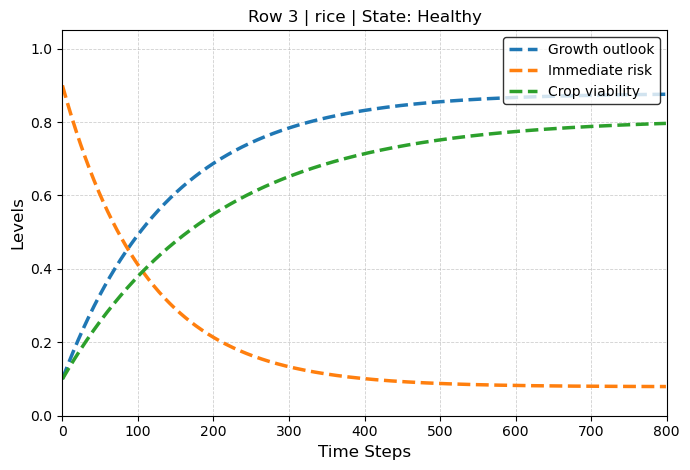

In [5]:
figures_dir = PROJECT_ROOT / "results" / "figures"
row_id = 3
sample_sim = trajectories[row_id]
sample_crop = feature_df.iloc[row_id]["label"]

fig = plot_crop_trajectory(sample_sim, crop_label=sample_crop, row_id=row_id)
display(fig)
save_figure(fig, figures_dir / "sample_crop_trajectory.png")
plt.close(fig)


## State Distribution and Viability Patterns


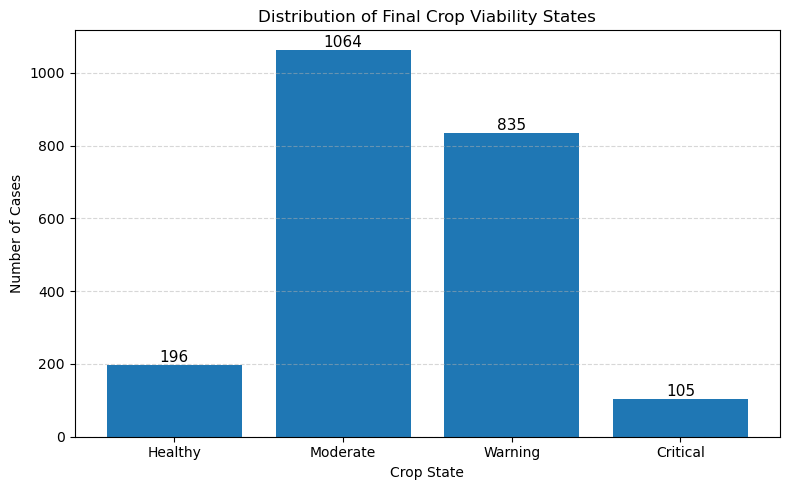

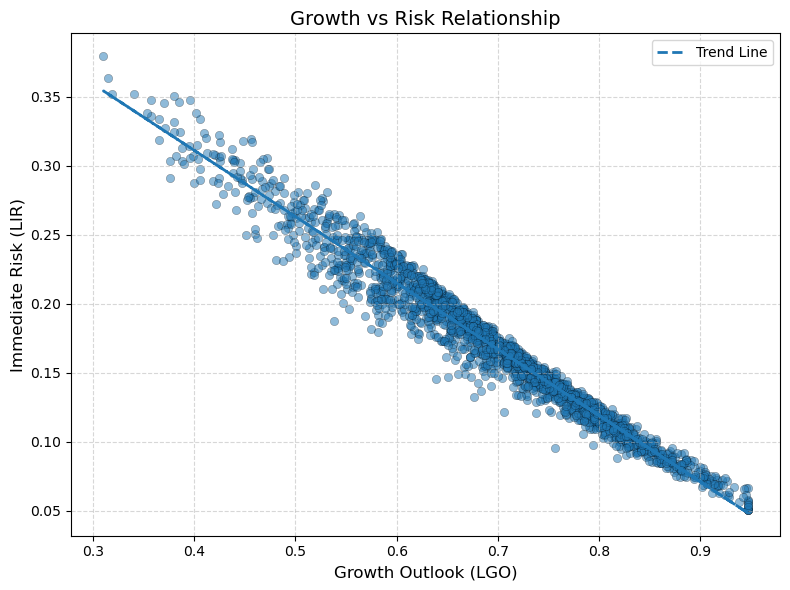

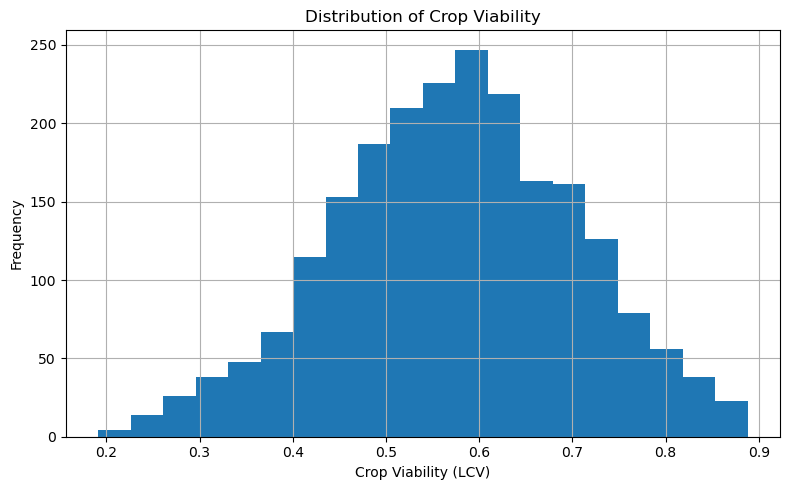

In [6]:
fig1 = plot_crop_state_distribution(results_df)
fig2 = plot_growth_risk_scatter(results_df)
fig3 = plot_viability_distribution(results_df)

for fig, name in [
    (fig1, "crop_state_distribution.png"),
    (fig2, "growth_vs_risk.png"),
    (fig3, "viability_distribution.png"),
]:
    display(fig)
    save_figure(fig, figures_dir / name)
    plt.close(fig)


## Interpretable Feature Diagnostics

These plots keep the model transparent by connecting the nine composite indicators back to the final crop viability outcomes.


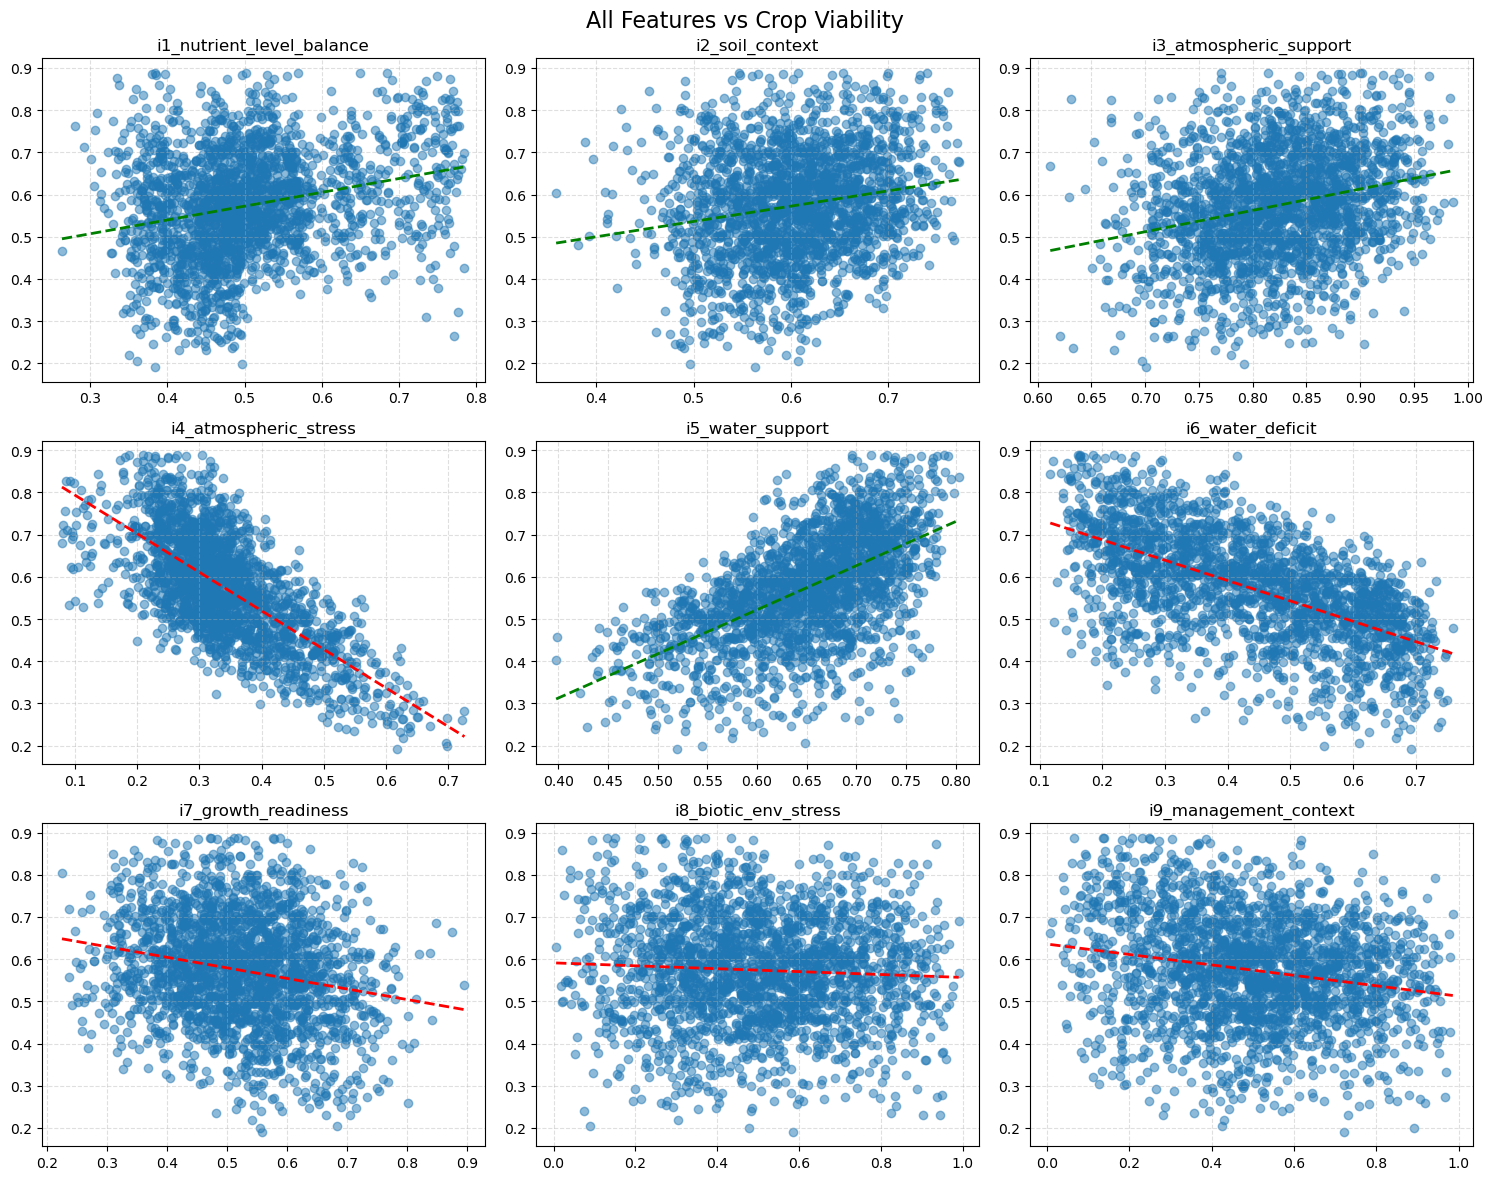

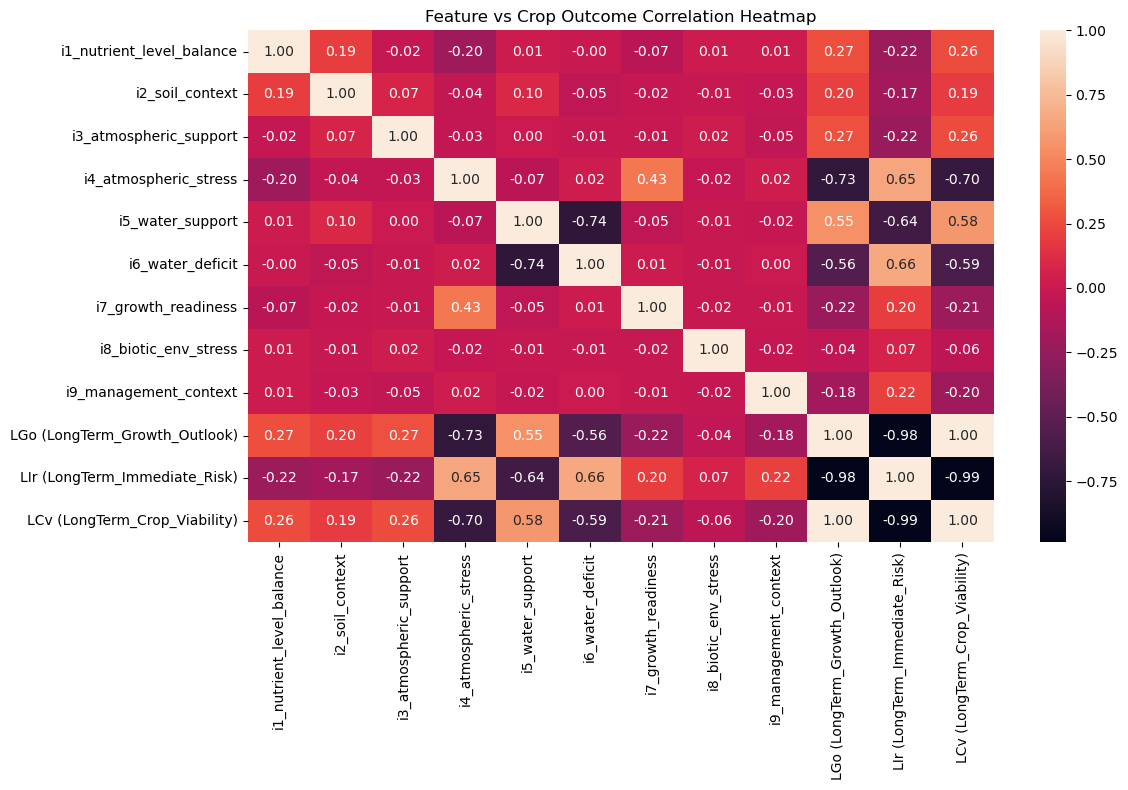

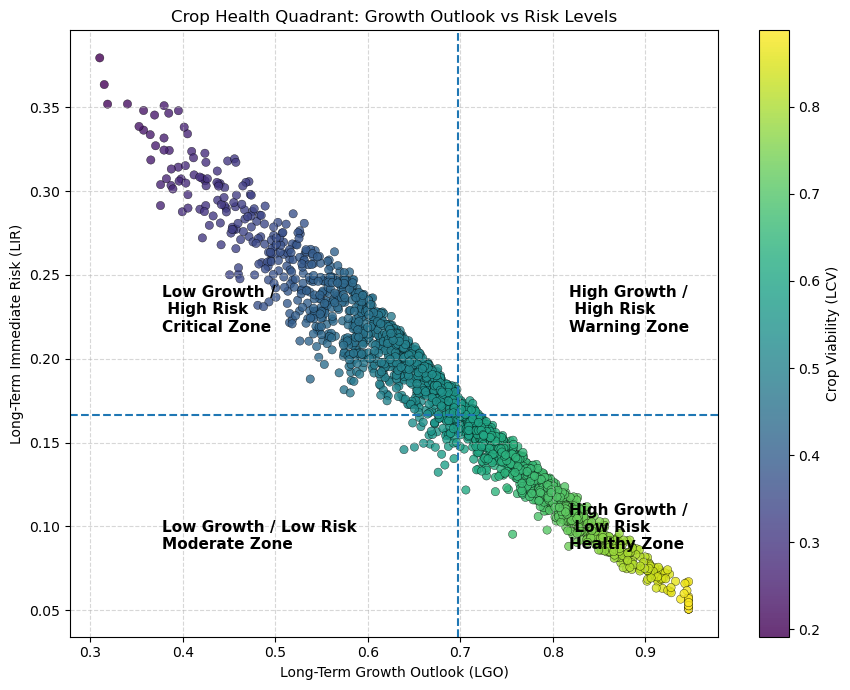

In [7]:
fig4 = plot_feature_vs_viability_grid(feature_df, results_df)
fig5 = plot_correlation_heatmap(feature_df, results_df)
fig6 = plot_crop_health_quadrant(results_df)

for fig, name in [
    (fig4, "feature_vs_viability_grid.png"),
    (fig5, "correlation_heatmap.png"),
    (fig6, "crop_health_quadrant.png"),
]:
    display(fig)
    save_figure(fig, figures_dir / name)
    plt.close(fig)


## Correlation-Based Driver Review

This final section highlights which aggregated features align most strongly with long-term crop viability in the current simulation outputs.


,feature,target,correlation,importance
10,i4_atmospheric_stress,Growth Outlook,-0.729864,0.729864
9,i4_atmospheric_stress,Crop Viability,-0.696363,0.696363
17,i6_water_deficit,Immediate Risk,0.657784,0.657784
11,i4_atmospheric_stress,Immediate Risk,0.645997,0.645997
14,i5_water_support,Immediate Risk,-0.638510,0.638510
15,i6_water_deficit,Crop Viability,-0.593039,0.593039
12,i5_water_support,Crop Viability,0.577711,0.577711
16,i6_water_deficit,Growth Outlook,-0.555164,0.555164
13,i5_water_support,Growth Outlook,0.547576,0.547576
7,i3_atmospheric_support,Growth Outlook,0.272755,0.272755


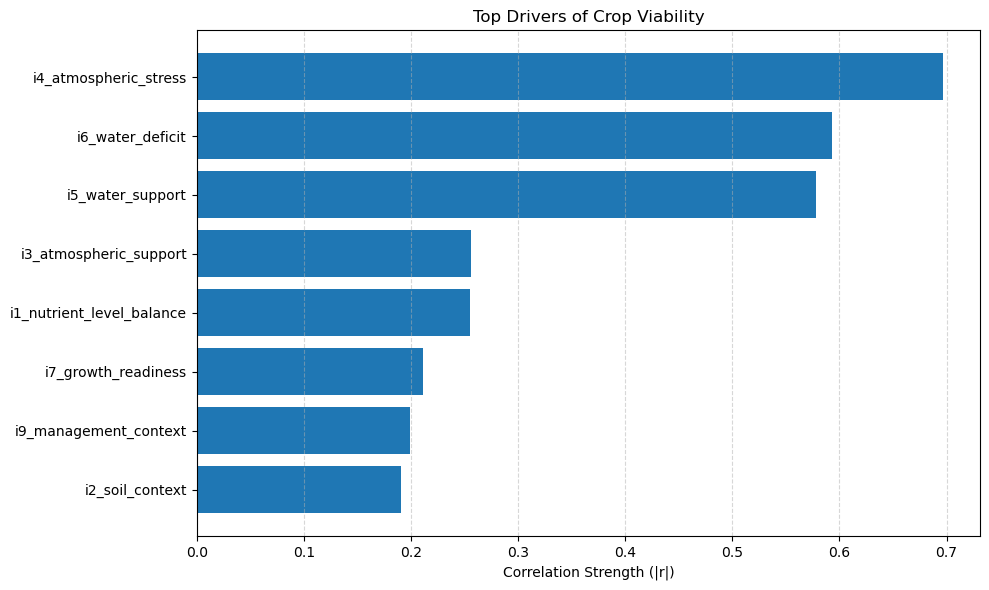

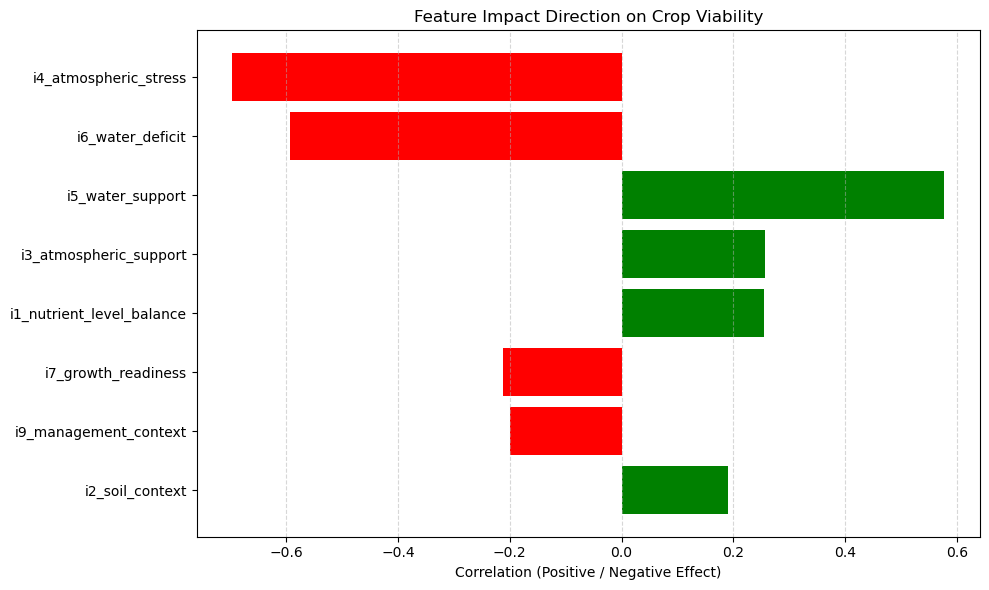

In [8]:
importance_df = calculate_feature_importance(feature_df, results_df)
display(importance_df.head(15))

fig7 = plot_top_feature_importance(importance_df)
fig8 = plot_feature_impact_direction(importance_df)

for fig, name in [
    (fig7, "top_feature_importance.png"),
    (fig8, "feature_impact_direction.png"),
]:
    display(fig)
    save_figure(fig, figures_dir / name)
    plt.close(fig)


## Saved Outputs

The result table is saved to `results/crop_health_results.csv`, and the figure assets are saved to `results/figures/`
